# Notebook 2: Exploratory Data Analysis
**Dataset:** Sample Superstore (Cleaned)  

**Goal:** Understand business performance across regions, categories, and customer segments. Identify where the business is strong and where it is struggling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')


## Section 1: Load Data


In [2]:
df = pd.read_csv('../data/processed/superstore_cleaned.csv', parse_dates=['Order Date', 'Ship Date'], dtype={'Postal Code': 'string'})
print(df.shape)
df.head()


(9993, 25)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Shipping Days,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,3,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,3,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,4,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,7,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,7,0.1125


## Section 2: Sales & Profit by Category


In [3]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
category_summary['Profit Margin %'] = (category_summary['Profit'] / category_summary['Sales'] * 100).round(2)
category_summary.sort_values('Sales', ascending=False)


,Category,Sales,Profit,Profit Margin %
2,Technology,836154.0330,145454.9481,17.40
0,Furniture,741718.4233,18463.3316,2.49
1,Office Supplies,719047.0320,122490.8008,17.04


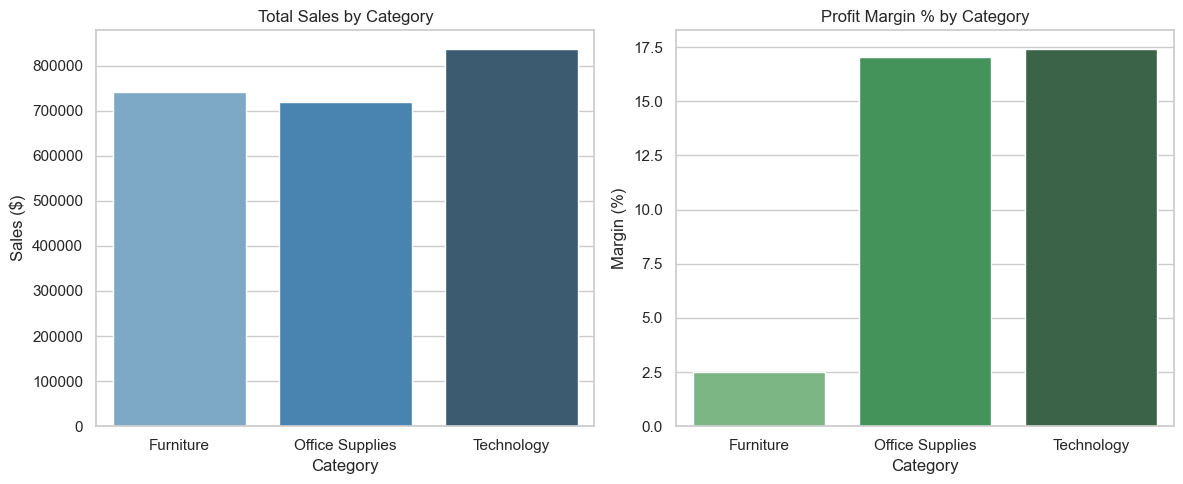

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=category_summary,
    x='Category',
    y='Sales',
    hue='Category',
    ax=axes[0],
    palette='Blues_d',
    legend=False
)
axes[0].set_title('Total Sales by Category')
axes[0].set_ylabel('Sales ($)')

sns.barplot(
    data=category_summary,
    x='Category',
    y='Profit Margin %',
    hue='Category',
    ax=axes[1],
    palette='Greens_d',
    legend=False
)
axes[1].set_title('Profit Margin % by Category')
axes[1].set_ylabel('Margin (%)')

plt.tight_layout()
plt.savefig('../outputs/figures/02_category_performance.png', dpi=150, bbox_inches='tight')
plt.show()


**Finding:** Technology leads in both revenue ($836K) and margin (17.4%). 
Office Supplies is highly efficient at 17% margin. Furniture generates $741K 
in sales but only 2.49% margin — indicating a significant profitability problem 
likely driven by over-discounting. Will be investigated in Notebook 3.


## Section 3: Sales & Profit by Region


In [5]:
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()
region_summary['Profit Margin %'] = (region_summary['Profit'] / region_summary['Sales'] * 100).round(2)
region_summary.sort_values('Sales', ascending=False)


,Region,Sales,Profit,Profit Margin %
3,West,725457.8245,108418.4489,14.94
1,East,678499.8680,91534.8388,13.49
0,Central,501239.8908,39706.3625,7.92
2,South,391721.9050,46749.4303,11.93


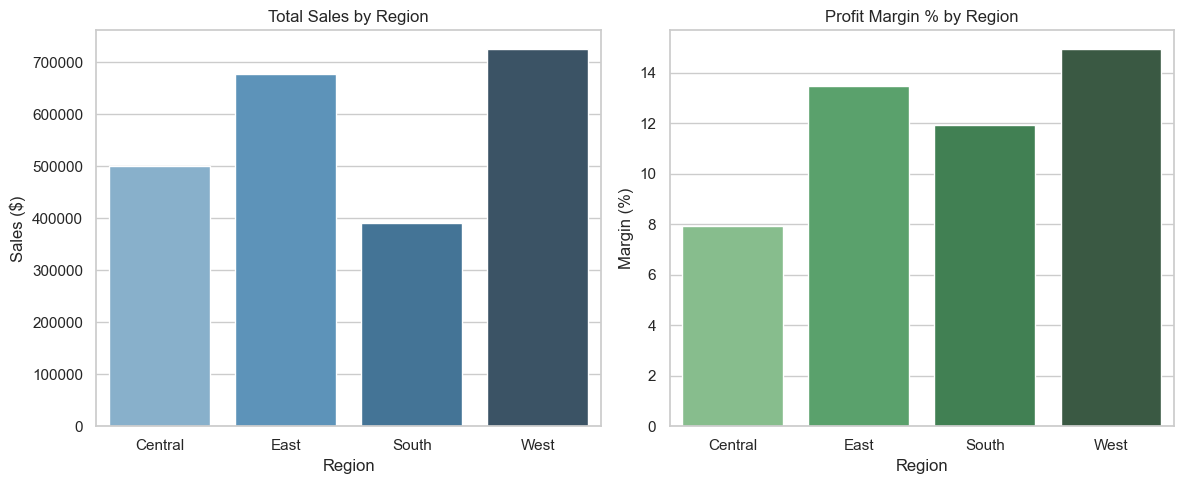

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=region_summary,
    x='Region',
    y='Sales',
    hue='Region',
    ax=axes[0],
    palette='Blues_d',
    legend=False
)
axes[0].set_title('Total Sales by Region')
axes[0].set_ylabel('Sales ($)')

sns.barplot(
    data=region_summary,
    x='Region',
    y='Profit Margin %',
    hue='Region',
    ax=axes[1],
    palette='Greens_d',
    legend=False
)
axes[1].set_title('Profit Margin % by Region')
axes[1].set_ylabel('Margin (%)')

plt.tight_layout()
plt.savefig('../outputs/figures/02_region_performance.png', dpi=150, bbox_inches='tight')
plt.show()


**Finding:** West region leads in both sales ($725K) and profit margin (14.94%). 
Central is the underperforming region — third in sales but lowest margin at 7.92%, 
nearly half of West's margin. Central will require further investigation into 
discounting practices in Notebook 3.


## Section 4: Sales & Profit by Customer Segment


In [7]:
segment_summary = df.groupby('Segment')[['Sales', 'Profit']].sum().reset_index()
segment_summary['Profit Margin %'] = (segment_summary['Profit'] / segment_summary['Sales'] * 100).round(2)
segment_summary.sort_values('Sales', ascending=False)


,Segment,Sales,Profit,Profit Margin %
0,Consumer,1.161401e+06,134119.2092,11.55
1,Corporate,7.061464e+05,91979.1340,13.03
2,Home Office,4.293718e+05,60310.7373,14.05


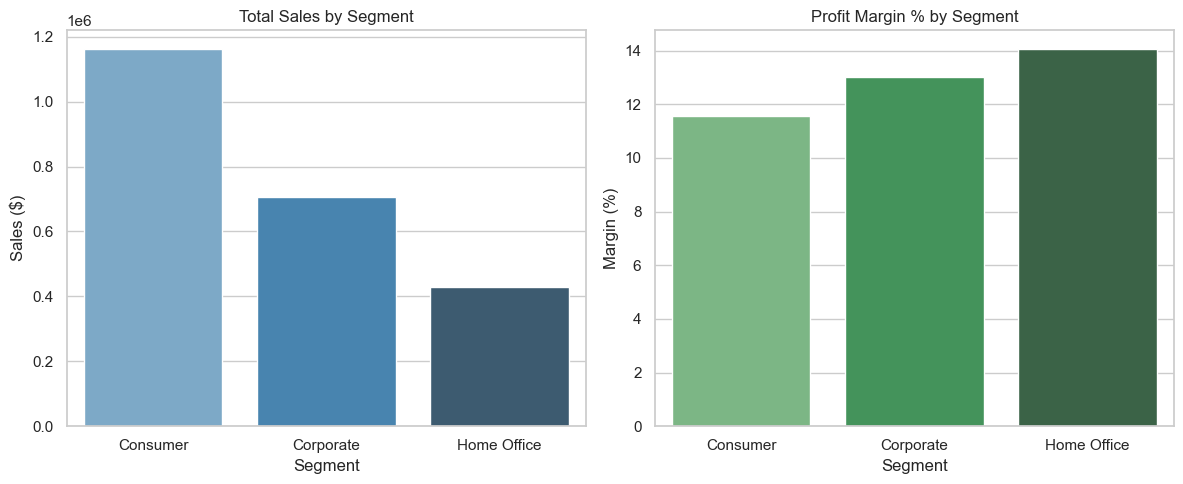

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=segment_summary,
    x='Segment',
    y='Sales',
    hue='Segment',
    ax=axes[0],
    palette='Blues_d',
    legend=False
)
axes[0].set_title('Total Sales by Segment')
axes[0].set_ylabel('Sales ($)')

sns.barplot(
    data=segment_summary,
    x='Segment',
    y='Profit Margin %',
    hue='Segment',
    ax=axes[1],
    palette='Greens_d',
    legend=False
)
axes[1].set_title('Profit Margin % by Segment')
axes[1].set_ylabel('Margin (%)')

plt.tight_layout()
plt.savefig('../outputs/figures/02_segment_performance.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Consumer segment drives the most revenue ($1.16M) but has the lowest 
profit margin (11.55%). Home Office has the smallest revenue base ($429K) but the 
highest margin (14.05%). Corporate is the most balanced segment. 
Insight: growing the Home Office and Corporate segments could improve overall 
profitability without needing to increase sales volume.


## Section 5: Top & Bottom Sub-Categories by Profit


In [9]:
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().reset_index()
subcategory_profit = subcategory_profit.sort_values('Profit', ascending=False).reset_index(drop=True)

bottom7 = subcategory_profit.tail(7)
top10 = subcategory_profit[~subcategory_profit['Sub-Category'].isin(bottom7['Sub-Category'])].head(10)

print("Top 10:")
print(top10)
print("\nBottom 7:")
print(bottom7)


Top 10:
  Sub-Category      Profit
0      Copiers  55617.8249
1       Phones  44515.7306
2  Accessories  41936.6357
3        Paper  34053.5693
4      Binders  30221.7633
5       Chairs  26602.2251
6      Storage  21278.8264
7   Appliances  18138.0054
8  Furnishings  13059.1436
9    Envelopes   6964.1767

Bottom 7:
   Sub-Category      Profit
10          Art   6527.7870
11       Labels   5546.2540
12     Machines   3384.7569
13    Fasteners    949.5182
14     Supplies  -1189.0995
15    Bookcases  -3472.5560
16       Tables -17725.4811


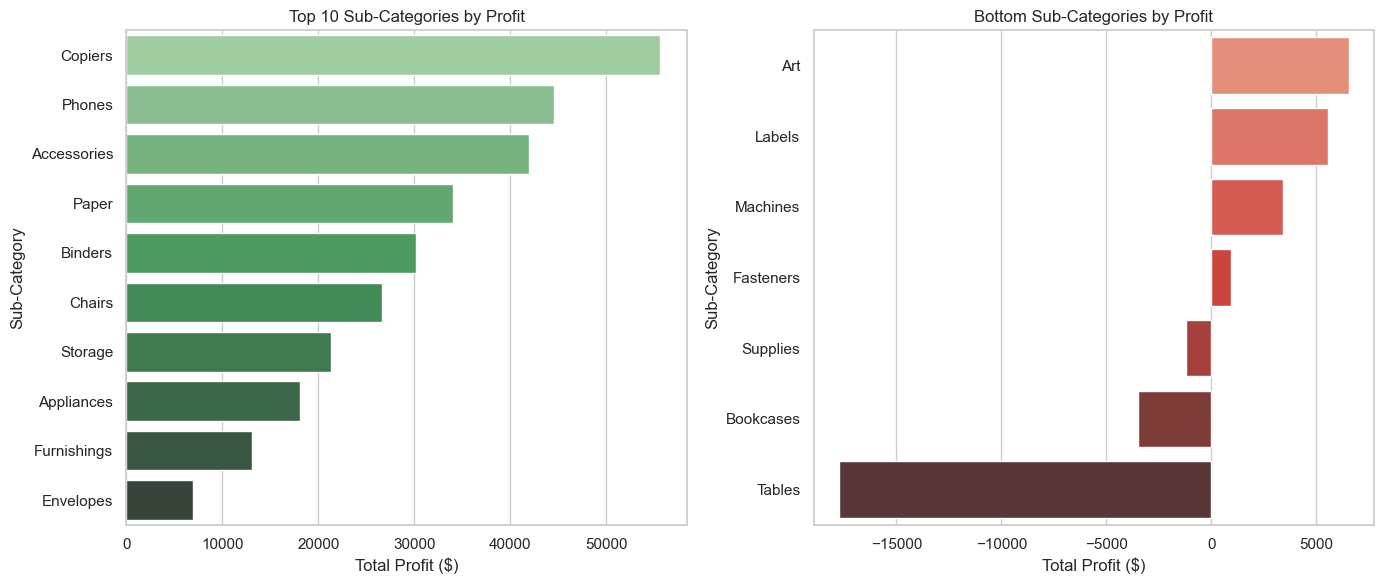

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=top10, x='Profit', y='Sub-Category', ax=axes[0],
            hue='Sub-Category', palette='Greens_d', legend=False)
axes[0].set_title('Top 10 Sub-Categories by Profit')
axes[0].set_xlabel('Total Profit ($)')

sns.barplot(data=bottom7, x='Profit', y='Sub-Category', ax=axes[1],
            hue='Sub-Category', palette='Reds_d', legend=False)
axes[1].set_title('Bottom Sub-Categories by Profit')
axes[1].set_xlabel('Total Profit ($)')

plt.tight_layout()
plt.savefig('../outputs/figures/02_subcategory_profit.png', dpi=150, bbox_inches='tight')
plt.show()


**Finding:** Copiers ($55.6K), Phones ($44.5K), and Accessories ($41.9K) are 
the top profit drivers. Tables is the single worst sub-category at -$17,725 in 
total losses, followed by Bookcases (-$3,472) and Supplies (-$1,189). 
All three loss-making sub-categories belong to the Furniture category — 
confirming Furniture's profitability problem is concentrated in Tables specifically.


## Section 6: Sales Trend Over Time


In [11]:
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Order Year', 'Order Month']].assign(Day=1).rename(columns={'Order Year': 'year', 'Order Month': 'month'}))
monthly_sales = monthly_sales.sort_values('Date')

monthly_sales.head()


,Order Year,Order Month,Sales,Date
0,2014,1,14236.895,2014-01-01
1,2014,2,4519.892,2014-02-01
2,2014,3,55691.009,2014-03-01
3,2014,4,28013.973,2014-04-01
4,2014,5,23648.287,2014-05-01


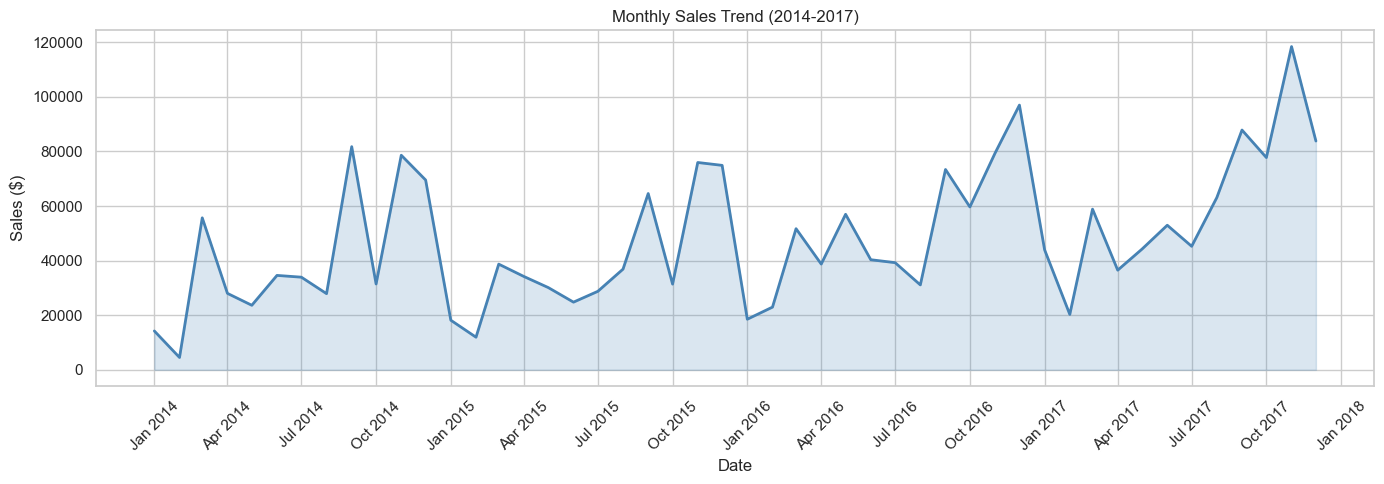

In [12]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    monthly_sales['Date'],
    monthly_sales['Sales'],
    color='steelblue',
    linewidth=2
)

ax.fill_between(
    monthly_sales['Date'],
    monthly_sales['Sales'],
    alpha=0.2,
    color='steelblue'
)

ax.set_title('Monthly Sales Trend (2014-2017)')
ax.set_xlabel('Date')
ax.set_ylabel('Sales ($)')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/02_monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

**Key Findings:**
- Technology leads in revenue ($836K) and margin (17.4%) — the strongest category
- Furniture generates $741K in sales but only 2.49% margin — driven by Tables at -$17,725 in losses
- West region outperforms all others; Central is underperforming at 7.92% margin
- Consumer segment drives the most revenue but has the lowest margin (11.55%)
- Clear Q4 seasonality every year with consistent Q1 weakness
- Overall sales are growing year over year — peaks reached $120K in late 2017

**What needs deeper investigation:**
- Why is Furniture/Tables losing money? (Notebook 3)
- Which customers are most valuable? (Notebook 4)
